In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df =pd.read_csv('mymoviedb.csv', lineterminator='\n')

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
        9837 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [6]:
# Things need to be change
# Release_Date into date_time data type
# vote_count into int data type
# vote_average into foating data type

In [7]:
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [8]:
# we will remove the empty space

In [11]:
# checking the duplicate move names
df.duplicated().sum()

np.int64(0)

In [14]:
# performing the basic statistics
# only possible in numeric data type
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [15]:
# Convert Vote_Count to integer
df['Vote_Count'] = pd.to_numeric(
    df['Vote_Count'],
    errors='coerce'
).fillna(0).astype(int)

In [16]:
# Convert Vote_Average to float
df['Vote_Average'] = pd.to_numeric(
    df['Vote_Average'],
    errors='coerce'
).astype(float)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9837 non-null   int64  
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
        9837 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.8+ KB


In [18]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9837.000000,9826.000000
mean,40.320570,1391.386093,6.439467
std,108.874308,2610.258502,1.129797
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,443.000000,6.500000
75%,35.174500,1375.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [19]:
exploration_summary = """
• We have a dataframe consisting of 9827 rows and 9 columns.
• Our dataset looks a bit tidy with no NaNs or duplicated values.
• Release_Date column needs to be casted into datetime and extract only the year value.
• Overview, Original_Language and Poster_Url column wouldn't be so useful during analysis, so we'll drop them.
• There is noticeable outliers in Popularity column.
• Vote_Average better be categorised for proper analysis.
• Genre column has comma separated values and white spaces that needs to be handled and casted into category.
"""

In [22]:
df['Release_Date'] = pd.to_datetime(
    df['Release_Date'],
    errors='coerce',
    dayfirst=True
)

print(df['Release_Date'].dtype)

datetime64[ns]


In [23]:
df['Release_Date']= df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('float64')

In [24]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,2021.0,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022.0,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022.0,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021.0,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021.0,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [26]:
# Dropping the columns

In [31]:
cols =['Overview','Original_Language','Poster_Url\r']

In [34]:
print(df.columns)

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')


In [36]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,6.3,Thriller
3,2021.0,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [37]:
# categorizing Vote_Average column
# We would cut the Vote_Average values and make 4 popular average below_avg not_popular
# to describe it more using cotigorize_col() function provided below

In [38]:
def catigorize_col(df, col, labels):

    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]

    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')

    return df

In [40]:
labels = ['not_popular','below_avg','average','popular']
catigorize_col(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [41]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,below_avg,Thriller
3,2021.0,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [42]:
df['Vote_Average'].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2411
below_avg,2398


In [44]:
df.dropna(inplace=True)
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [45]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,below_avg,Thriller
3,2021.0,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [46]:
# we would split genres into list and then explode our dateframe to have only
# one genre per row fpr each movie

In [47]:
df['Genre'] = df['Genre'].str.split(', ')
df =df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022.0,The Batman,3827.658,1151,popular,Crime
4,2022.0,The Batman,3827.658,1151,popular,Mystery


In [48]:
# casting column into category

df['Genre']=df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25551 non-null  float64 
 1   Title         25551 non-null  object  
 2   Popularity    25551 non-null  float64 
 3   Vote_Count    25551 non-null  int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25551 non-null  category
dtypes: category(2), float64(2), int64(1), object(1)
memory usage: 849.4+ KB


In [50]:
df.nunique()

,0
Release_Date,100
Title,9414
Popularity,8087
Vote_Count,3265
Vote_Average,4
Genre,19


In [51]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022.0,The Batman,3827.658,1151,popular,Crime
4,2022.0,The Batman,3827.658,1151,popular,Mystery


In [53]:
# Data Visualization

In [60]:
sns.set_style('darkgrid')

#What is the most frequent genre of movie relesed on netflix?

In [57]:
df['Genre'].describe()

,Genre
count,25551
unique,19
top,Drama
freq,3715


<function matplotlib.pyplot.show(close=None, block=None)>

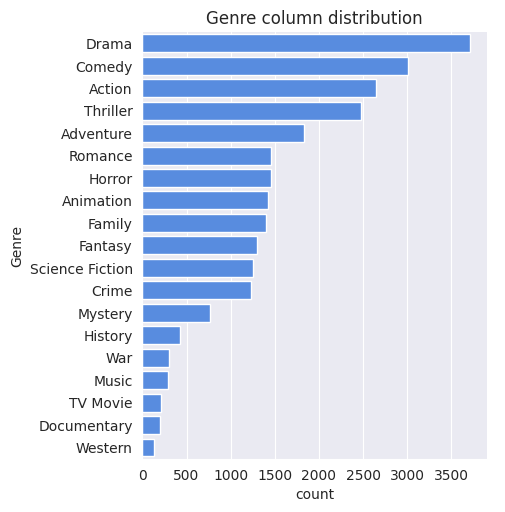

In [61]:
sns.catplot(y='Genre',data=df,kind='count',order=df['Genre'].value_counts().index,
            color='#4287f5')

plt.title('Genre column distribution')
plt.show



The distribution shows that Drama is the most dominant movie genre, followed by Comedy and Action. Genres like Thriller and Adventure also have a strong presence in the dataset. On the other hand, genres such as Western, Documentary, and TV Movie have the lowest number of movies. Overall, the dataset mainly focuses on drama and entertainment-oriented genres.

#Which has the highest votes in avg column

In [62]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022.0,The Batman,3827.658,1151,popular,Crime
4,2022.0,The Batman,3827.658,1151,popular,Mystery


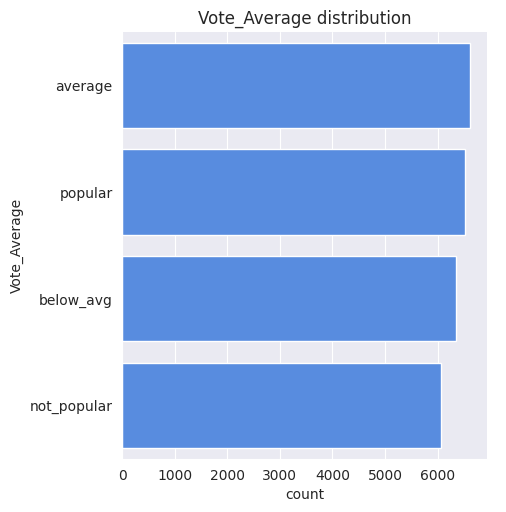

In [64]:
sns.catplot(y='Vote_Average', data = df, kind ='count',
            order =df['Vote_Average'].value_counts().index,
            color='#4287f5')
plt.title('Vote_Average distribution')

plt.show()

The chart shows that the movie ratings are distributed almost evenly across all four categories: not_popular, below_avg, average, and popular. Among them, the average category has the highest number of movies, while not_popular has the lowest. The small difference in counts indicates a balanced distribution of vote averages in the dataset. Overall, most movies fall between average and popular ratings.

#What movie got the highest popularity? what's genre?


In [65]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Adventure


In [67]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


Answer : Spider-Man: No Way Home

#What movie got the lowest popularity? what's it's genre?

In [68]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25545,2021.0,The United States vs. Billie Holiday,13.354,152,average,Music
25546,2021.0,The United States vs. Billie Holiday,13.354,152,average,Drama
25547,2021.0,The United States vs. Billie Holiday,13.354,152,average,History
25548,1984.0,Threads,13.354,186,popular,War
25549,1984.0,Threads,13.354,186,popular,Drama
25550,1984.0,Threads,13.354,186,popular,Science Fiction


Answer : The United States vs. Billie Holiday

#Which year has the most filmmed movies?

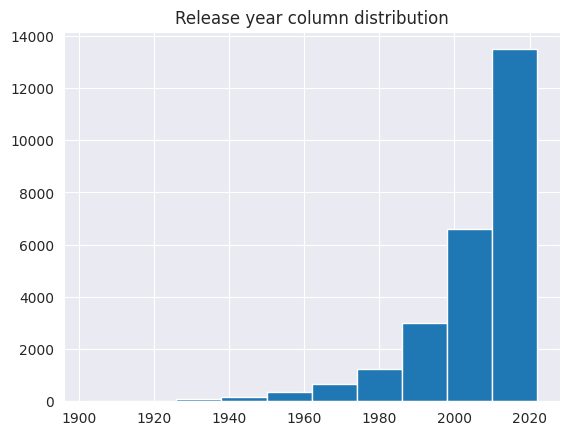

In [71]:
df['Release_Date'].hist()
plt.title("Release year column distribution")
plt.show()

The distribution indicates that the number of movie releases has increased significantly over the years. Most movies in the dataset were released after the year 2000, showing a rapid growth in film production in recent decades. Very few movies were released before 1980, resulting in a highly right-skewed distribution. Overall, modern-era movies dominate the dataset.

In [72]:
# Project Summary:

# Cleaned and analyzed a movie dataset using Pandas and NumPy.
# Converted datatypes:
# Release_Date → datetime/year
# Vote_Count → integer
# Vote_Average → float
# Handled invalid and missing values using:
# pd.to_numeric()
# pd.to_datetime()
# errors='coerce'
# Created a user-defined function to categorize movie ratings into:
# not_popular
# below_avg
# average
# popular
# Split movies with multiple genres into separate rows for better genre analysis.
# Performed Exploratory Data Analysis (EDA) using visualizations.
# Found that:
# Drama, Comedy, and Action are the most common genres.
# Most movies were released after 2000.
# Vote average categories are almost evenly distributed.
# Overall, the project demonstrates data cleaning, preprocessing, transformation, and visualization techniques in Python for meaningful movie data analysis.